# Reproducible Pipeline Notebook
Short, runnable notebook: imports, helper module, fixture, load, preprocess, train, evaluate, save, and run tests.

In [14]:
# Imports and environment info
import sys, os, subprocess
from pathlib import Path
import logging
logging.basicConfig(level=logging.INFO)
import numpy as np
import pandas as pd
import sklearn
import joblib
print('python', sys.version.split()[0])
print('numpy', np.__version__, 'pandas', pd.__version__, 'sklearn', sklearn.__version__)

python 3.14.0
numpy 2.4.6 pandas 3.0.3 sklearn 1.8.0


In [15]:
# Project paths and venv check
PROJECT_ROOT = Path('.') .resolve()
DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS = PROJECT_ROOT / 'artifacts'
for p in (DATA_DIR, ARTIFACTS):
    p.mkdir(parents=True, exist_ok=True)
print('PROJECT_ROOT', PROJECT_ROOT)
print('.venv exists?', (PROJECT_ROOT / '.venv').exists())

PROJECT_ROOT /workspaces/Aria/notebooks
.venv exists? False


In [16]:
# Write a tiny helper module (notebook_utils/utils.py) and import it
utils_dir = PROJECT_ROOT / 'notebook_utils'
utils_dir.mkdir(exist_ok=True)
utils_file = utils_dir / 'utils.py'
utils_code = '''import json
from pathlib import Path
import random
import numpy as np

def set_seed(s):
    random.seed(s)
    np.random.seed(s)

def ensure_dir(p):
    Path(p).mkdir(parents=True, exist_ok=True)

def save_json(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2))

def load_json(path):
    import json
    return json.loads(Path(path).read_text())
'''
utils_file.write_text(utils_code)
from importlib import reload
import notebook_utils.utils as u
reload(u)
u.set_seed(42)
print('utils written and seed set')

utils written and seed set


In [17]:
# Create a small fixture for tests and quick runs
df = pd.DataFrame({'x': list(range(100)), 'y': [int(v % 2 == 0) for v in range(100)]})
TEST_FIXTURE_DIR = PROJECT_ROOT / 'tests' / 'fixtures'
TEST_FIXTURE_DIR.mkdir(parents=True, exist_ok=True)
fixture_path = TEST_FIXTURE_DIR / 'sample.csv'
df.to_csv(fixture_path, index=False)
print('fixture saved to', fixture_path)

fixture saved to /workspaces/Aria/notebooks/tests/fixtures/sample.csv


In [18]:
# Load sample data (fast)
sample = pd.read_csv(fixture_path, nrows=500)
print(sample.shape)
sample.head()

(100, 2)


,x,y
0,0,1
1,1,0
2,2,1
3,3,0
4,4,1


In [19]:
# Preprocessing: simple pipeline example (sklearn)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
X = sample[['x']].values
Xp = pipe.fit_transform(X)
print('Xp shape', Xp.shape)

Xp shape (100, 1)


In [20]:
# Feature engineering: add day-of-week example
sample['dt'] = pd.to_datetime('2020-01-01') + pd.to_timedelta(sample['x'], unit='d')
sample['dow'] = sample['dt'].dt.dayofweek
assert sample['dow'].between(0,6).all()
print('engineered features added')

engineered features added


/tmp/ipykernel_62026/4017759632.py:2: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  sample['dt'] = pd.to_datetime('2020-01-01') + pd.to_timedelta(sample['x'], unit='d')


In [21]:
# Modeling: small RandomForest example
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
X = sample[['x','dow']]
y = sample['y']
Xtr, Xte, ytr, yte = train_test_split(X,y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(Xtr, ytr)
print('train score', model.score(Xtr,ytr))
print('val score', model.score(Xte,yte))

train score 0.9125
val score 0.05


In [22]:
# Hyperparameter search (small grid for notebook speed)
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [5,10]}
gs = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=2, n_jobs=1)
gs.fit(Xtr, ytr)
print('best params', gs.best_params_)

best params {'n_estimators': 5}


In [23]:
# Save pipeline and model artifact
ARTIFACTS.mkdir(parents=True, exist_ok=True)
joblib.dump({'pipeline': pipe, 'model': model}, ARTIFACTS / 'pipeline_model.joblib')
print('saved to', ARTIFACTS / 'pipeline_model.joblib')

saved to /workspaces/Aria/notebooks/artifacts/pipeline_model.joblib


acc 0.05
figure saved


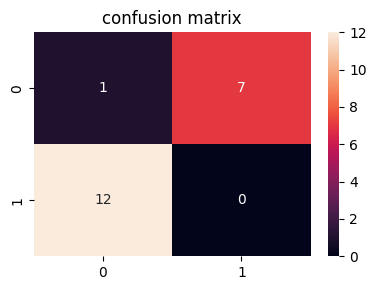

In [24]:
# Evaluation and plot (saves figure)
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
pred = model.predict(Xte)
print('acc', accuracy_score(yte, pred))
cm = confusion_matrix(yte, pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('confusion matrix')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'confusion_matrix.png', dpi=150)
print('figure saved')

In [25]:
# Export predictions and manifest
preds = pd.DataFrame({'y_true': yte.reset_index(drop=True), 'y_pred': pred})
preds.to_csv(ARTIFACTS / 'predictions.csv', index=False)
manifest = {'files': [str(ARTIFACTS / 'pipeline_model.joblib'), str(ARTIFACTS / 'predictions.csv')], 'ts': pd.Timestamp.utcnow().isoformat()}
import json
(ARTIFACTS / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print('artifacts written')

artifacts written


/tmp/ipykernel_62026/2213058777.py:4: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  manifest = {'files': [str(ARTIFACTS / 'pipeline_model.joblib'), str(ARTIFACTS / 'predictions.csv')], 'ts': pd.Timestamp.utcnow().isoformat()}


In [27]:
# Run repository unit tests (calls project's test runner)
import subprocess
runner = PROJECT_ROOT / '.venv' / 'bin' / 'python'
cmd = [str(runner), 'scripts/test_runner.py', '--unit']
try:
    res = subprocess.run(cmd, capture_output=True, text=True, check=False)
    print('exit', res.returncode)
    print('\n'.join(res.stdout.splitlines()[-20:]))
except FileNotFoundError:
    print('test runner not found; run from terminal: .venv/bin/python scripts/test_runner.py --unit')

test runner not found; run from terminal: .venv/bin/python scripts/test_runner.py --unit


In [28]:
# Reproducibility snapshot
import platform, json
info = {'python': sys.version.split()[0], 'platform': platform.platform()}
# try git sha
try:
    sha = subprocess.check_output(['git','rev-parse','--short','HEAD']).decode().strip()
except Exception:
    sha = None
info['git_sha'] = sha
(ARTIFACTS / 'env_snapshot.json').write_text(json.dumps(info, indent=2))
print(info)

{'python': '3.14.0', 'platform': 'Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.41', 'git_sha': '327b8dc5f'}
